In [1]:
from keras.utils import to_categorical
from keras_preprocessing.image import load_img
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D
import os
import pandas as pd
import numpy as np


In [2]:
TRAIN_DIR = 'images/train'
TEST_DIR = 'images/test'

In [3]:
def createdataframe(dir):
    image_paths = []
    labels = []
    for label in os.listdir(dir):
        for imagename in os.listdir(os.path.join(dir,label)):
            image_paths.append(os.path.join(dir,label,imagename))
            labels.append(label)
        print(label, "completed")
    return image_paths,labels


In [4]:
train = pd.DataFrame()
train['image'], train['label'] = createdataframe(TRAIN_DIR)

angry completed
disgust completed
fear completed
happy completed
neutral completed
sad completed
surprise completed


In [5]:
print(train)

                                image     label
0            images/train\angry\0.jpg     angry
1            images/train\angry\1.jpg     angry
2           images/train\angry\10.jpg     angry
3        images/train\angry\10002.jpg     angry
4        images/train\angry\10016.jpg     angry
...                               ...       ...
28816  images/train\surprise\9969.jpg  surprise
28817  images/train\surprise\9985.jpg  surprise
28818  images/train\surprise\9990.jpg  surprise
28819  images/train\surprise\9992.jpg  surprise
28820  images/train\surprise\9996.jpg  surprise

[28821 rows x 2 columns]


In [6]:
test = pd.DataFrame()
test['image'], test['label'] = createdataframe(TEST_DIR)

angry completed
disgust completed
fear completed
happy completed
neutral completed
sad completed
surprise completed


In [7]:
print(test)
print(test['image'])

                              image     label
0       images/test\angry\10052.jpg     angry
1       images/test\angry\10065.jpg     angry
2       images/test\angry\10079.jpg     angry
3       images/test\angry\10095.jpg     angry
4       images/test\angry\10121.jpg     angry
...                             ...       ...
7061  images/test\surprise\9806.jpg  surprise
7062  images/test\surprise\9830.jpg  surprise
7063  images/test\surprise\9853.jpg  surprise
7064  images/test\surprise\9878.jpg  surprise
7065   images/test\surprise\993.jpg  surprise

[7066 rows x 2 columns]
0         images/test\angry\10052.jpg
1         images/test\angry\10065.jpg
2         images/test\angry\10079.jpg
3         images/test\angry\10095.jpg
4         images/test\angry\10121.jpg
                    ...              
7061    images/test\surprise\9806.jpg
7062    images/test\surprise\9830.jpg
7063    images/test\surprise\9853.jpg
7064    images/test\surprise\9878.jpg
7065     images/test\surprise\993.jpg
Name:

In [13]:
from tqdm import tqdm

In [9]:
def extract_features(images):
    features = []
    for image in tqdm(images):
        img = load_img(image,grayscale =  True )
        img = np.array(img)
        features.append(img)
    features = np.array(features)
    features = features.reshape(len(features),48,48,1)
    return features

In [14]:
train_features = extract_features(train['image']) 



  0%|                                                       | 0/28821 [00:00<?, ?it/s]C:\Users\sumet\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras_preprocessing\image\utils.py:107: UserWarning: grayscale is deprecated. Please use color_mode = "grayscale"
  warnings.warn('grayscale is deprecated. Please use '


  0%|                                             | 1/28821 [00:00<3:29:52,  2.29it/s]

  0%|                                               | 8/28821 [00:00<26:05, 18.41it/s]

  0%|                                              | 16/28821 [00:00<14:27, 33.22it/s]

  0%|                                              | 23/28821 [00:00<11:26, 41.95it/s]

  0%|                                              | 29/28821 [00:00<10:56, 43.88it/s]

  0%|                                              | 38/28821 [00:01<08:50, 54.30it/s]

  0%|                                              | 45/28821 [00:01<08:33, 56.07it/s]

  0%|                                              |

  2%|▉                                            | 637/28821 [00:10<06:38, 70.73it/s]

  2%|█                                            | 645/28821 [00:10<06:55, 67.77it/s]

  2%|█                                            | 653/28821 [00:10<06:46, 69.31it/s]

  2%|█                                            | 661/28821 [00:10<07:29, 62.66it/s]

  2%|█                                            | 669/28821 [00:10<07:12, 65.14it/s]

  2%|█                                            | 677/28821 [00:10<06:49, 68.80it/s]

  2%|█                                            | 685/28821 [00:10<06:42, 69.93it/s]

  2%|█                                            | 693/28821 [00:10<07:24, 63.30it/s]

  2%|█                                            | 701/28821 [00:11<07:05, 66.05it/s]

  2%|█                                            | 710/28821 [00:11<06:40, 70.10it/s]

  2%|█                                            | 719/28821 [00:11<06:17, 74.41it/s]

  3%|█▏                         

  5%|██                                          | 1336/28821 [00:20<06:48, 67.25it/s]

  5%|██                                          | 1343/28821 [00:20<06:46, 67.56it/s]

  5%|██                                          | 1351/28821 [00:20<06:31, 70.23it/s]

  5%|██                                          | 1360/28821 [00:20<06:03, 75.46it/s]

  5%|██                                          | 1368/28821 [00:20<06:05, 75.12it/s]

  5%|██                                          | 1376/28821 [00:20<06:05, 75.08it/s]

  5%|██                                          | 1385/28821 [00:20<05:56, 76.89it/s]

  5%|██▏                                         | 1394/28821 [00:20<05:50, 78.21it/s]

  5%|██▏                                         | 1402/28821 [00:20<06:17, 72.60it/s]

  5%|██▏                                         | 1410/28821 [00:21<06:27, 70.75it/s]

  5%|██▏                                         | 1418/28821 [00:21<06:29, 70.29it/s]

  5%|██▏                        

  7%|███                                         | 2009/28821 [00:30<06:37, 67.45it/s]

  7%|███                                         | 2016/28821 [00:30<07:38, 58.40it/s]

  7%|███                                         | 2024/28821 [00:30<07:08, 62.55it/s]

  7%|███                                         | 2033/28821 [00:30<06:35, 67.74it/s]

  7%|███                                         | 2042/28821 [00:30<06:11, 71.99it/s]

  7%|███▏                                        | 2050/28821 [00:30<06:20, 70.42it/s]

  7%|███▏                                        | 2058/28821 [00:31<06:22, 69.99it/s]

  7%|███▏                                        | 2066/28821 [00:31<06:11, 72.00it/s]

  7%|███▏                                        | 2075/28821 [00:31<05:58, 74.51it/s]

  7%|███▏                                        | 2084/28821 [00:31<05:48, 76.71it/s]

  7%|███▏                                        | 2092/28821 [00:31<05:57, 74.83it/s]

  7%|███▏                       

  9%|████▏                                       | 2702/28821 [00:40<06:15, 69.64it/s]

  9%|████▏                                       | 2710/28821 [00:40<06:11, 70.35it/s]

  9%|████▏                                       | 2718/28821 [00:40<06:06, 71.18it/s]

  9%|████▏                                       | 2726/28821 [00:40<06:07, 70.93it/s]

  9%|████▏                                       | 2734/28821 [00:40<06:46, 64.21it/s]

 10%|████▏                                       | 2741/28821 [00:41<06:55, 62.80it/s]

 10%|████▏                                       | 2749/28821 [00:41<06:30, 66.81it/s]

 10%|████▏                                       | 2757/28821 [00:41<06:14, 69.56it/s]

 10%|████▏                                       | 2765/28821 [00:41<06:00, 72.36it/s]

 10%|████▏                                       | 2773/28821 [00:41<05:51, 74.08it/s]

 10%|████▏                                       | 2782/28821 [00:41<05:42, 75.92it/s]

 10%|████▎                      

...

 89%|██████████████████████████████████████▏    | 25580/28821 [06:00<00:44, 72.40it/s]

 89%|██████████████████████████████████████▏    | 25588/28821 [06:00<00:44, 73.03it/s]

 89%|██████████████████████████████████████▏    | 25596/28821 [06:01<00:45, 70.17it/s]

 89%|██████████████████████████████████████▏    | 25604/28821 [06:01<00:44, 71.93it/s]

 89%|██████████████████████████████████████▏    | 25613/28821 [06:01<00:42, 74.80it/s]

 89%|██████████████████████████████████████▏    | 25621/28821 [06:01<00:45, 70.34it/s]

 89%|██████████████████████████████████████▏    | 25629/28821 [06:01<00:47, 67.67it/s]

 89%|██████████████████████████████████████▎    | 25638/28821 [06:01<00:43, 73.30it/s]

 89%|██████████████████████████████████████▎    | 25646/28821 [06:01<00:43, 72.69it/s]

 89%|██████████████████████████████████████▎    | 25655/28821 [06:01<00:42, 75.33it/s]

 89%|██████████████████████████████████████▎    | 25664/28821 [06:01<00:41, 76.82it/s]

 89%|███████████████████████████

 91%|███████████████████████████████████████▎   | 26313/28821 [06:10<00:33, 75.18it/s]

 91%|███████████████████████████████████████▎   | 26322/28821 [06:10<00:32, 77.70it/s]

 91%|███████████████████████████████████████▎   | 26330/28821 [06:10<00:32, 75.94it/s]

 91%|███████████████████████████████████████▎   | 26340/28821 [06:11<00:30, 81.07it/s]

 91%|███████████████████████████████████████▎   | 26350/28821 [06:11<00:29, 84.61it/s]

 91%|███████████████████████████████████████▎   | 26359/28821 [06:11<00:30, 81.65it/s]

 91%|███████████████████████████████████████▎   | 26368/28821 [06:11<00:30, 81.69it/s]

 92%|███████████████████████████████████████▎   | 26377/28821 [06:11<00:29, 83.80it/s]

 92%|███████████████████████████████████████▎   | 26386/28821 [06:11<00:28, 84.28it/s]

 92%|███████████████████████████████████████▍   | 26395/28821 [06:11<00:28, 84.74it/s]

 92%|███████████████████████████████████████▍   | 26404/28821 [06:11<00:29, 80.79it/s]

 92%|███████████████████████████

 94%|████████████████████████████████████████▍  | 27095/28821 [06:20<00:20, 82.69it/s]

 94%|████████████████████████████████████████▍  | 27104/28821 [06:20<00:20, 81.79it/s]

 94%|████████████████████████████████████████▍  | 27114/28821 [06:20<00:20, 84.55it/s]

 94%|████████████████████████████████████████▍  | 27123/28821 [06:20<00:20, 82.38it/s]

 94%|████████████████████████████████████████▍  | 27133/28821 [06:20<00:19, 85.82it/s]

 94%|████████████████████████████████████████▍  | 27142/28821 [06:21<00:20, 83.10it/s]

 94%|████████████████████████████████████████▌  | 27151/28821 [06:21<00:20, 79.57it/s]

 94%|████████████████████████████████████████▌  | 27160/28821 [06:21<00:22, 72.33it/s]

 94%|████████████████████████████████████████▌  | 27170/28821 [06:21<00:21, 78.15it/s]

 94%|████████████████████████████████████████▌  | 27181/28821 [06:21<00:19, 83.75it/s]

 94%|████████████████████████████████████████▌  | 27190/28821 [06:21<00:19, 84.83it/s]

 94%|███████████████████████████

 97%|█████████████████████████████████████████▌ | 27882/28821 [06:30<00:12, 73.42it/s]

 97%|█████████████████████████████████████████▌ | 27890/28821 [06:30<00:13, 71.47it/s]

 97%|█████████████████████████████████████████▋ | 27903/28821 [06:30<00:10, 86.79it/s]

 97%|█████████████████████████████████████████▋ | 27912/28821 [06:30<00:10, 87.62it/s]

 97%|█████████████████████████████████████████▋ | 27922/28821 [06:30<00:10, 88.83it/s]

 97%|█████████████████████████████████████████▋ | 27932/28821 [06:31<00:10, 88.45it/s]

 97%|█████████████████████████████████████████▋ | 27941/28821 [06:31<00:10, 83.98it/s]

 97%|█████████████████████████████████████████▋ | 27950/28821 [06:31<00:10, 80.30it/s]

 97%|█████████████████████████████████████████▋ | 27960/28821 [06:31<00:10, 83.09it/s]

 97%|█████████████████████████████████████████▋ | 27972/28821 [06:31<00:09, 90.31it/s]

 97%|█████████████████████████████████████████▋ | 27982/28821 [06:31<00:09, 88.85it/s]

 97%|███████████████████████████

100%|██████████████████████████████████████████▊| 28714/28821 [06:40<00:01, 87.42it/s]

100%|██████████████████████████████████████████▊| 28724/28821 [06:40<00:01, 88.46it/s]

100%|██████████████████████████████████████████▊| 28737/28821 [06:40<00:00, 99.17it/s]

100%|██████████████████████████████████████████▉| 28748/28821 [06:40<00:00, 88.63it/s]

100%|██████████████████████████████████████████▉| 28758/28821 [06:41<00:00, 85.88it/s]

100%|██████████████████████████████████████████▉| 28767/28821 [06:41<00:00, 86.53it/s]

100%|██████████████████████████████████████████▉| 28776/28821 [06:41<00:00, 86.63it/s]

100%|██████████████████████████████████████████▉| 28785/28821 [06:41<00:00, 85.92it/s]

100%|██████████████████████████████████████████▉| 28796/28821 [06:41<00:00, 89.94it/s]

100%|██████████████████████████████████████████▉| 28806/28821 [06:41<00:00, 89.82it/s]

100%|███████████████████████████████████████████| 28821/28821 [06:41<00:00, 71.74it/s]


In [15]:
test_features = extract_features(test['image'])



  0%|                                                        | 0/7066 [00:00<?, ?it/s]

  0%|                                                | 6/7066 [00:00<02:00, 58.83it/s]

  0%|                                               | 13/7066 [00:00<01:51, 63.47it/s]

  0%|▏                                              | 21/7066 [00:00<01:42, 68.44it/s]

  0%|▏                                              | 29/7066 [00:00<01:38, 71.33it/s]

  1%|▏                                              | 37/7066 [00:00<01:37, 72.23it/s]

  1%|▎                                              | 45/7066 [00:00<01:52, 62.45it/s]

  1%|▎                                              | 52/7066 [00:00<01:54, 61.46it/s]

  1%|▍                                              | 60/7066 [00:00<01:47, 64.93it/s]

  1%|▍                                              | 68/7066 [00:01<01:45, 66.55it/s]

  1%|▌                                              | 76/7066 [00:01<01:41, 68.66it/s]

  1%|▌                        

 10%|████▋                                         | 727/7066 [00:09<01:23, 75.95it/s]

 10%|████▊                                         | 735/7066 [00:10<01:28, 71.93it/s]

 11%|████▊                                         | 743/7066 [00:10<01:25, 73.88it/s]

 11%|████▉                                         | 751/7066 [00:10<01:24, 74.82it/s]

 11%|████▉                                         | 759/7066 [00:10<01:28, 71.46it/s]

 11%|████▉                                         | 767/7066 [00:10<01:27, 72.28it/s]

 11%|█████                                         | 776/7066 [00:10<01:22, 76.60it/s]

 11%|█████                                         | 784/7066 [00:10<01:32, 68.03it/s]

 11%|█████▏                                        | 792/7066 [00:10<01:30, 68.97it/s]

 11%|█████▏                                        | 801/7066 [00:10<01:24, 74.34it/s]

 11%|█████▎                                        | 809/7066 [00:11<01:24, 73.73it/s]

 12%|█████▎                     

 20%|█████████▏                                   | 1441/7066 [00:19<01:20, 70.03it/s]

 21%|█████████▏                                   | 1449/7066 [00:20<01:25, 65.94it/s]

 21%|█████████▎                                   | 1457/7066 [00:20<01:23, 67.47it/s]

 21%|█████████▎                                   | 1465/7066 [00:20<01:19, 70.03it/s]

 21%|█████████▍                                   | 1474/7066 [00:20<01:16, 73.18it/s]

 21%|█████████▍                                   | 1483/7066 [00:20<01:13, 75.76it/s]

 21%|█████████▍                                   | 1491/7066 [00:20<01:24, 66.21it/s]

 21%|█████████▌                                   | 1498/7066 [00:20<01:23, 66.56it/s]

 21%|█████████▌                                   | 1507/7066 [00:20<01:18, 71.04it/s]

 21%|█████████▋                                   | 1516/7066 [00:20<01:15, 73.77it/s]

 22%|█████████▋                                   | 1524/7066 [00:21<01:13, 75.43it/s]

 22%|█████████▊                 

 30%|█████████████▋                               | 2151/7066 [00:29<01:03, 77.44it/s]

 31%|█████████████▊                               | 2160/7066 [00:29<01:02, 78.57it/s]

 31%|█████████████▊                               | 2168/7066 [00:30<01:10, 69.57it/s]

 31%|█████████████▊                               | 2176/7066 [00:30<01:11, 68.40it/s]

 31%|█████████████▉                               | 2184/7066 [00:30<01:11, 68.75it/s]

 31%|█████████████▉                               | 2191/7066 [00:30<01:19, 61.31it/s]

 31%|██████████████                               | 2199/7066 [00:30<01:14, 64.93it/s]

 31%|██████████████                               | 2208/7066 [00:30<01:09, 69.47it/s]

 31%|██████████████                               | 2216/7066 [00:30<01:07, 71.88it/s]

 31%|██████████████▏                              | 2224/7066 [00:30<01:16, 63.71it/s]

 32%|██████████████▏                              | 2233/7066 [00:31<01:10, 68.45it/s]

 32%|██████████████▎            

 40%|██████████████████                           | 2836/7066 [00:39<01:08, 61.49it/s]

 40%|██████████████████                           | 2844/7066 [00:40<01:04, 65.60it/s]

 40%|██████████████████▏                          | 2852/7066 [00:40<01:02, 67.85it/s]

 40%|██████████████████▏                          | 2859/7066 [00:40<01:02, 67.69it/s]

 41%|██████████████████▎                          | 2867/7066 [00:40<01:00, 69.39it/s]

 41%|██████████████████▎                          | 2874/7066 [00:40<01:08, 61.58it/s]

 41%|██████████████████▎                          | 2883/7066 [00:40<01:02, 67.23it/s]

 41%|██████████████████▍                          | 2891/7066 [00:40<01:00, 69.35it/s]

 41%|██████████████████▍                          | 2900/7066 [00:40<00:57, 72.94it/s]

 41%|██████████████████▌                          | 2908/7066 [00:40<00:55, 74.30it/s]

 41%|██████████████████▌                          | 2916/7066 [00:41<00:54, 75.58it/s]

 41%|██████████████████▌        

...

 60%|██████████████████████████▊                  | 4205/7066 [00:59<00:38, 74.62it/s]

 60%|██████████████████████████▊                  | 4213/7066 [00:59<00:43, 65.04it/s]

 60%|██████████████████████████▉                  | 4220/7066 [00:59<00:43, 65.18it/s]

 60%|██████████████████████████▉                  | 4228/7066 [01:00<00:41, 68.35it/s]

 60%|██████████████████████████▉                  | 4235/7066 [01:00<00:41, 68.79it/s]

 60%|███████████████████████████                  | 4242/7066 [01:00<00:44, 63.64it/s]

 60%|███████████████████████████                  | 4249/7066 [01:00<00:43, 64.81it/s]

 60%|███████████████████████████                  | 4256/7066 [01:00<00:42, 65.93it/s]

 60%|███████████████████████████▏                 | 4264/7066 [01:00<00:40, 68.76it/s]

 60%|███████████████████████████▏                 | 4273/7066 [01:00<00:38, 72.62it/s]

 61%|███████████████████████████▎                 | 4281/7066 [01:00<00:41, 66.76it/s]

 61%|███████████████████████████

 69%|███████████████████████████████▏             | 4903/7066 [01:09<00:27, 77.76it/s]

 70%|███████████████████████████████▎             | 4911/7066 [01:09<00:32, 65.61it/s]

 70%|███████████████████████████████▎             | 4919/7066 [01:09<00:31, 68.39it/s]

 70%|███████████████████████████████▍             | 4927/7066 [01:09<00:30, 69.57it/s]

 70%|███████████████████████████████▍             | 4935/7066 [01:09<00:33, 64.50it/s]

 70%|███████████████████████████████▍             | 4942/7066 [01:10<00:33, 63.73it/s]

 70%|███████████████████████████████▌             | 4949/7066 [01:10<00:33, 63.24it/s]

 70%|███████████████████████████████▌             | 4957/7066 [01:10<00:31, 67.40it/s]

 70%|███████████████████████████████▌             | 4964/7066 [01:10<00:31, 66.28it/s]

 70%|███████████████████████████████▋             | 4971/7066 [01:10<00:33, 61.76it/s]

 70%|███████████████████████████████▋             | 4978/7066 [01:10<00:33, 62.80it/s]

 71%|███████████████████████████

 79%|███████████████████████████████████▌         | 5590/7066 [01:19<00:19, 75.82it/s]

 79%|███████████████████████████████████▋         | 5598/7066 [01:19<00:20, 72.62it/s]

 79%|███████████████████████████████████▋         | 5606/7066 [01:19<00:21, 67.53it/s]

 79%|███████████████████████████████████▊         | 5615/7066 [01:19<00:20, 71.93it/s]

 80%|███████████████████████████████████▊         | 5623/7066 [01:19<00:21, 67.59it/s]

 80%|███████████████████████████████████▊         | 5630/7066 [01:19<00:22, 64.17it/s]

 80%|███████████████████████████████████▉         | 5638/7066 [01:20<00:20, 68.16it/s]

 80%|███████████████████████████████████▉         | 5646/7066 [01:20<00:20, 70.18it/s]

 80%|████████████████████████████████████         | 5654/7066 [01:20<00:20, 69.15it/s]

 80%|████████████████████████████████████         | 5661/7066 [01:20<00:21, 65.46it/s]

 80%|████████████████████████████████████         | 5670/7066 [01:20<00:19, 70.15it/s]

 80%|███████████████████████████

 89%|████████████████████████████████████████     | 6299/7066 [01:29<00:10, 73.61it/s]

 89%|████████████████████████████████████████▏    | 6307/7066 [01:29<00:11, 66.85it/s]

 89%|████████████████████████████████████████▏    | 6314/7066 [01:29<00:11, 63.11it/s]

 89%|████████████████████████████████████████▎    | 6322/7066 [01:29<00:11, 66.63it/s]

 90%|████████████████████████████████████████▎    | 6329/7066 [01:29<00:11, 66.20it/s]

 90%|████████████████████████████████████████▎    | 6336/7066 [01:29<00:11, 63.82it/s]

 90%|████████████████████████████████████████▍    | 6344/7066 [01:29<00:10, 67.59it/s]

 90%|████████████████████████████████████████▍    | 6351/7066 [01:30<00:10, 67.76it/s]

 90%|████████████████████████████████████████▌    | 6360/7066 [01:30<00:09, 72.97it/s]

 90%|████████████████████████████████████████▌    | 6368/7066 [01:30<00:10, 65.60it/s]

 90%|████████████████████████████████████████▌    | 6376/7066 [01:30<00:10, 68.69it/s]

 90%|███████████████████████████

100%|████████████████████████████████████████████▊| 7044/7066 [01:39<00:00, 71.51it/s]

100%|████████████████████████████████████████████▉| 7054/7066 [01:39<00:00, 77.35it/s]

100%|█████████████████████████████████████████████| 7066/7066 [01:39<00:00, 70.92it/s]


In [16]:
x_train = train_features/255.0
x_test = test_features/255.0

In [17]:
from sklearn.preprocessing import LabelEncoder

In [18]:
le = LabelEncoder()
le.fit(train['label'])

LabelEncoder()

In [19]:
y_train = le.transform(train['label'])
y_test = le.transform(test['label'])

In [20]:
y_train = to_categorical(y_train,num_classes = 7)
y_test = to_categorical(y_test,num_classes = 7)

In [21]:
model = Sequential()
# convolutional layers
model.add(Conv2D(128, kernel_size=(3,3), activation='relu', input_shape=(48,48,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(256, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(512, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(512, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Flatten())
# fully connected layers
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))
# output layer
model.add(Dense(7, activation='softmax'))

C:\Users\sumet\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [24]:
model.fit(x= x_train,y = y_train, batch_size = 128, epochs = 100, validation_data = (x_test,y_test)) 

Epoch 1/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 268s 1s/step - accuracy: 0.2379 - loss: 1.8378 - val_accuracy: 0.2583 - val_loss: 1.8107
Epoch 2/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 253s 1s/step - accuracy: 0.2506 - loss: 1.8110 - val_accuracy: 0.2624 - val_loss: 1.7732
Epoch 3/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2707 - loss: 1.7607

Exception ignored in: <function tqdm.__del__ at 0x0000021909A56D40>
Traceback (most recent call last):
  File "C:\Users\sumet\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "C:\Users\sumet\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'
Exception ignored in: <function tqdm.__del__ at 0x0000021909A56D40>
Traceback (most recent call last):
  File "C:\Users\sumet\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "C:\Users\sumet\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


KeyboardInterrupt: 

In [25]:
model_json = model.to_json()
with open("emotiondetector.json",'w') as json_file:
    json_file.write(model_json)
model.save("emotiondetector.h5")

In [26]:
from keras.models import model_from_json

In [29]:
from tensorflow.keras.models import model_from_json

with open("facialemotionmodel.json", "r") as json_file:
    model_json = json_file.read()

model = model_from_json(model_json)
model.load_weights("facialemotionmodel.h5")


TypeError: Could not locate class 'Sequential'. Make sure custom classes are decorated with `@keras.saving.register_keras_serializable()`. Full object config: {'class_name': 'Sequential', 'config': {'name': 'sequential', 'layers': [{'class_name': 'InputLayer', 'config': {'batch_input_shape': [None, 48, 48, 1], 'dtype': 'float32', 'sparse': False, 'ragged': False, 'name': 'conv2d_input'}}, {'class_name': 'Conv2D', 'config': {'name': 'conv2d', 'trainable': True, 'batch_input_shape': [None, 48, 48, 1], 'dtype': 'float32', 'filters': 128, 'kernel_size': [3, 3], 'strides': [1, 1], 'padding': 'valid', 'data_format': 'channels_last', 'dilation_rate': [1, 1], 'groups': 1, 'activation': 'relu', 'use_bias': True, 'kernel_initializer': {'class_name': 'GlorotUniform', 'config': {'seed': None}}, 'bias_initializer': {'class_name': 'Zeros', 'config': {}}, 'kernel_regularizer': None, 'bias_regularizer': None, 'activity_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}}, {'class_n

In [31]:
from tensorflow.keras.models import load_model

# Load old H5 model in TF-Keras
model.load_weights("facialemotionmodel.h5")  # load old weights into your model

# Save properly in new format
model.save("facialemotionmodel.keras")


In [32]:
from tensorflow.keras.models import load_model

model = load_model("facialemotionmodel.keras")


C:\Users\sumet\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 16 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [33]:
import keras
keras.config.enable_unsafe_deserialization()  # allow legacy JSON deserialization

from tensorflow.keras.models import model_from_json

with open("facialemotionmodel.json", "r") as json_file:
    model_json = json_file.read()

model = model_from_json(model_json)
model.load_weights("facialemotionmodel.h5")


TypeError: Could not locate class 'Sequential'. Make sure custom classes are decorated with `@keras.saving.register_keras_serializable()`. Full object config: {'class_name': 'Sequential', 'config': {'name': 'sequential', 'layers': [{'class_name': 'InputLayer', 'config': {'batch_input_shape': [None, 48, 48, 1], 'dtype': 'float32', 'sparse': False, 'ragged': False, 'name': 'conv2d_input'}}, {'class_name': 'Conv2D', 'config': {'name': 'conv2d', 'trainable': True, 'batch_input_shape': [None, 48, 48, 1], 'dtype': 'float32', 'filters': 128, 'kernel_size': [3, 3], 'strides': [1, 1], 'padding': 'valid', 'data_format': 'channels_last', 'dilation_rate': [1, 1], 'groups': 1, 'activation': 'relu', 'use_bias': True, 'kernel_initializer': {'class_name': 'GlorotUniform', 'config': {'seed': None}}, 'bias_initializer': {'class_name': 'Zeros', 'config': {}}, 'kernel_regularizer': None, 'bias_regularizer': None, 'activity_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}}, {'class_n

In [35]:
import keras
keras.config.enable_unsafe_deserialization()  # allow legacy JSON deserialization

from tensorflow.keras.models import model_from_json

with open("facialemotionmodel.json", "r") as json_file:
    model_json = json_file.read()

model = model_from_json(model_json)
model.load_weights("facialemotionmodel.h5")


TypeError: Could not locate class 'Sequential'. Make sure custom classes are decorated with `@keras.saving.register_keras_serializable()`. Full object config: {'class_name': 'Sequential', 'config': {'name': 'sequential', 'layers': [{'class_name': 'InputLayer', 'config': {'batch_input_shape': [None, 48, 48, 1], 'dtype': 'float32', 'sparse': False, 'ragged': False, 'name': 'conv2d_input'}}, {'class_name': 'Conv2D', 'config': {'name': 'conv2d', 'trainable': True, 'batch_input_shape': [None, 48, 48, 1], 'dtype': 'float32', 'filters': 128, 'kernel_size': [3, 3], 'strides': [1, 1], 'padding': 'valid', 'data_format': 'channels_last', 'dilation_rate': [1, 1], 'groups': 1, 'activation': 'relu', 'use_bias': True, 'kernel_initializer': {'class_name': 'GlorotUniform', 'config': {'seed': None}}, 'bias_initializer': {'class_name': 'Zeros', 'config': {}}, 'kernel_regularizer': None, 'bias_regularizer': None, 'activity_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}}, {'class_n

In [51]:
label = ['angry','disgust','fear','happy','neutral','sad','surprise']

In [52]:
def ef(image):
    img = load_img(image,grayscale =  True )
    feature = np.array(img)
    feature = feature.reshape(1,48,48,1)
    return feature/255.0
    

In [53]:
image = 'images/train/sad/42.jpg'
print("original image is of sad")
img = ef(image)
pred = model.predict(img)
pred_label = label[pred.argmax()]
print("model prediction is ",pred_label)

original image is of sad
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
model prediction is  sad


In [46]:
import matplotlib.pyplot as plt
%matplotlib inline

original image is of sad
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
model prediction is  sad


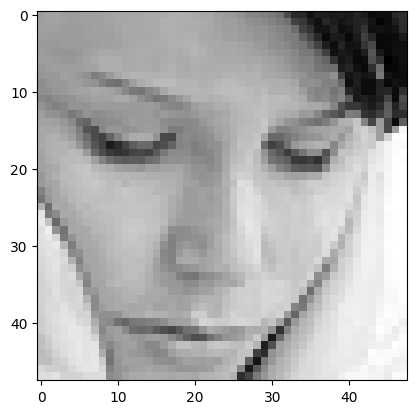

In [54]:
image = 'images/train/sad/42.jpg'
print("original image is of sad")
img = ef(image)
pred = model.predict(img)
pred_label = label[pred.argmax()]
print("model prediction is ",pred_label)
plt.imshow(img.reshape(48,48),cmap='gray')

original image is of fear
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
model prediction is  sad


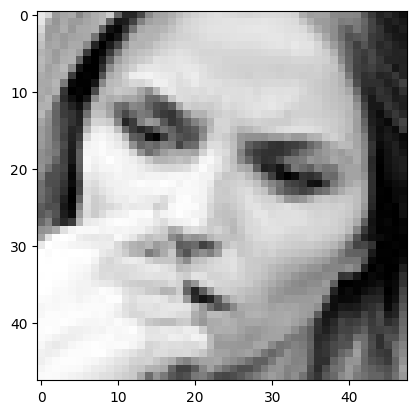

In [55]:
image = 'images/train/fear/2.jpg'
print("original image is of fear")
img = ef(image)
pred = model.predict(img)
pred_label = label[pred.argmax()]
print("model prediction is ",pred_label)
plt.imshow(img.reshape(48,48),cmap='gray')

original image is of disgust
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
model prediction is  disgust


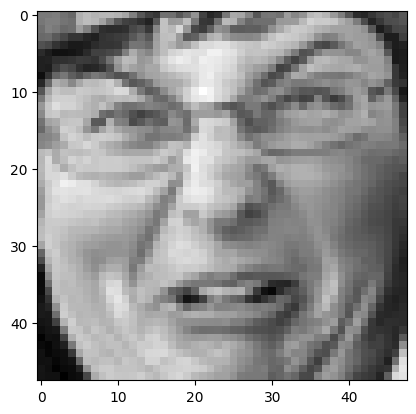

In [56]:
image = 'images/train/disgust/299.jpg'
print("original image is of disgust")
img = ef(image)
pred = model.predict(img)
pred_label = label[pred.argmax()]
print("model prediction is ",pred_label)
plt.imshow(img.reshape(48,48),cmap='gray')

original image is of happy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
model prediction is  happy


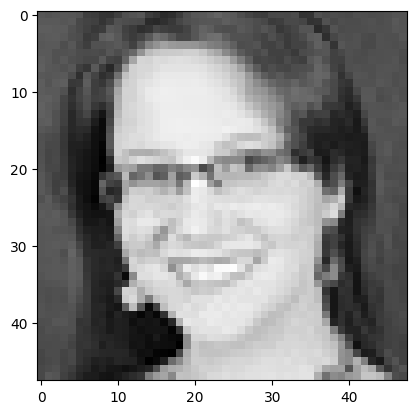

In [57]:
image = 'images/train/happy/7.jpg'
print("original image is of happy")
img = ef(image)
pred = model.predict(img)
pred_label = label[pred.argmax()]
print("model prediction is ",pred_label)
plt.imshow(img.reshape(48,48),cmap='gray')

original image is of surprise
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
model prediction is  surprise


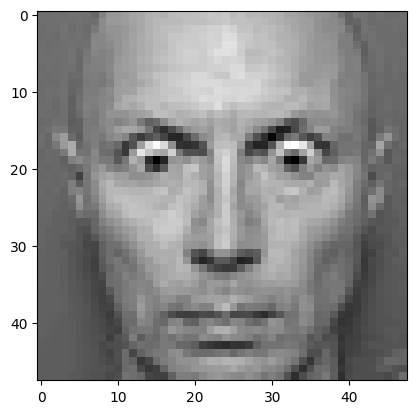

In [58]:
image = 'images/train/surprise/15.jpg'
print("original image is of surprise")
img = ef(image)
pred = model.predict(img)
pred_label = label[pred.argmax()]
print("model prediction is ",pred_label)
plt.imshow(img.reshape(48,48),cmap='gray')

In [59]:
from tensorflow.keras.models import model_from_json

# Load old JSON + H5
with open("facialemotionmodel.json", "r") as json_file:
    model_json = json_file.read()

model = model_from_json(model_json)
model.load_weights("facialemotionmodel.h5")

# Save as new Keras format
model.save("facialemotionmodel.keras")


TypeError: Could not locate class 'Sequential'. Make sure custom classes are decorated with `@keras.saving.register_keras_serializable()`. Full object config: {'class_name': 'Sequential', 'config': {'name': 'sequential', 'layers': [{'class_name': 'InputLayer', 'config': {'batch_input_shape': [None, 48, 48, 1], 'dtype': 'float32', 'sparse': False, 'ragged': False, 'name': 'conv2d_input'}}, {'class_name': 'Conv2D', 'config': {'name': 'conv2d', 'trainable': True, 'batch_input_shape': [None, 48, 48, 1], 'dtype': 'float32', 'filters': 128, 'kernel_size': [3, 3], 'strides': [1, 1], 'padding': 'valid', 'data_format': 'channels_last', 'dilation_rate': [1, 1], 'groups': 1, 'activation': 'relu', 'use_bias': True, 'kernel_initializer': {'class_name': 'GlorotUniform', 'config': {'seed': None}}, 'bias_initializer': {'class_name': 'Zeros', 'config': {}}, 'kernel_regularizer': None, 'bias_regularizer': None, 'activity_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}}, {'class_n